# RGB BNN systematics inspection (test split)

Reads the artifacts of a **finished** training run — no retraining — and joins
the test predictions (`targeted_prediction_summary.csv`) back onto the stellar
parameters, then looks for systematic trends of the age residuals with
metallicity, Teff, logg, chemistry, SNR, and label precision.

Default target: the **Kepler-only** run (`train_pipeline_rgb_kepler.ipynb` →
`BNN_targeted_output_RGB_kepler/`). To analyze the all-missions run instead,
point `OUTPUT_DIR` at `BNN_targeted_output_RGB` and set `SELECTION_FILE` to the
persisted classifier selection in section 2.

Reading guide:

- `residual = true − pred`, so a **positive** trend vs a parameter means stars
  at high values of that parameter are predicted **too young**.
- Raw residuals inherit the regression-to-the-mean slope: any parameter that
  correlates with age (Teff and logg do, strongly, along the giant branch) will
  show a trend that is *not* a real systematic. The **debiased** residuals have
  the mean age slope removed, so a trend that survives there is much closer to
  a genuine systematic. Judge with the paired table at the bottom.

## 1. Setup

In [10]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CANDIDATES = [
    '~/scr_mk27/bingo-modern',
    '~/code/bingo-modern',
    '.',
]
repo = next((p for p in map(os.path.expanduser, CANDIDATES)
             if os.path.isfile(os.path.join(p, 'prepare_dataset.py'))), None)
if repo is None:
    raise FileNotFoundError('Could not find prepare_dataset.py. Add its dir to CANDIDATES.')
repo = os.path.abspath(repo)
os.chdir(repo)
sys.path.insert(0, repo)
print('repo:', repo)

# The module twins of the notebook prep (drift-checked by the training
# notebook), used here only to rebuild the per-star parameters for the join.
import prepare_dataset as prep

repo: /home/100/mj8805/scr_mk27/bingo-modern


## 2. Configuration

In [11]:
DATASET = '~/scr_mk27/bulge-ages-and-orbits/data/merged_with_ages_raw.parquet'

# Which run to inspect. Kepler-only (default):
OUTPUT_DIR = Path('./BNN_targeted_output_RGB_kepler')
SELECTION_FILE = None
# All-missions run instead:
#   OUTPUT_DIR = Path('./BNN_targeted_output_RGB')
#   SELECTION_FILE = os.path.expanduser(
#       '~/scr_mk27/bulge-ages-and-orbits/data/rgb_selection_all_missions.parquet')

# Parameters to test the residuals against.
PARAMS = ['FE_H', 'M_H', 'MG_FE', 'C_N', 'TEFF', 'LOGG', 'SNR', 'logAgeErr']

## 3. Load predictions & rejoin stellar parameters

The prediction summary carries IDs but not the input features, so the catalog
is reloaded through the same selection the run used and joined on `APOGEE_ID`.
The join must be complete — a missing star means `OUTPUT_DIR` and
`SELECTION_FILE` do not describe the same run.

In [12]:
summary = pd.read_csv(OUTPUT_DIR / 'targeted_prediction_summary.csv')
print(f"{len(summary)} test-star predictions from "
      f"{OUTPUT_DIR / 'targeted_prediction_summary.csv'}")

cat = prep.load_willett_merged(os.path.expanduser(DATASET), target_state='rgb',
                               selection_file=SELECTION_FILE)
cat = (cat.sort_values('SNR', ascending=False)
          .drop_duplicates(prep.ID_COL, keep='first'))
cat = prep.derive_features(cat)

drop_cols = [c for c in cat.columns
             if c in summary.columns and c != prep.ID_COL]
d = summary.merge(cat.drop(columns=drop_cols), on=prep.ID_COL, how='left')
unmatched = int(d['TEFF'].isna().sum())
assert unmatched == 0, (
    f'{unmatched} test stars not found in the catalog -- OUTPUT_DIR and '
    'SELECTION_FILE probably do not describe the same run')
print(f'joined stellar parameters for {len(d)} test stars')
d.head()

650 test-star predictions from BNN_targeted_output_RGB_kepler/targeted_prediction_summary.csv
[merged catalog] 23708 rows -> 20808 with finite age_L; dropping sentinel=35, RelAge_L=False=4642, impostors=236 (overlapping) -> 15990 remain
[state] seismic EvoState==1 only: 3434 of 15990 rows kept (8156 rows have no seismic state -- mostly K2/TESS; pass selection_file to include their classified subset)
source
Kepler    3434
joined stellar parameters for 650 test stars


,APOGEE_ID,source,observational_uncertainty,model_uncertainty,intrinsic_scatter,total_predictive_uncertainty,pred_median,pred_mean_only,true_age,theoretical_total,...,C_FE_ERR,N_FE,N_FE_ERR,age,logAge,logAgeErr,C_N,C_N_ERR,M_H,M_H_ERR
0,2M19373722+3948079,Kepler,0.091948,0.099954,0.223309,0.293025,0.868713,0.856252,0.952056,0.261366,...,0.001732,0.161,0.002449,8.954801,0.952056,0.091948,-0.125,0.003000,-0.043355,0.001555
1,2M19393017+4354523,Kepler,0.043526,0.100147,0.223309,0.333081,0.199074,0.203616,-0.129262,0.248577,...,0.001732,0.287,0.001732,0.742571,-0.129262,0.043526,-0.261,0.002449,-0.205332,0.001446
2,2M19130136+4057375,Kepler,0.041681,0.099910,0.223309,0.325131,0.346256,0.344756,0.263440,0.248166,...,0.001732,0.360,0.001732,1.834172,0.263440,0.041681,-0.432,0.002449,-0.021393,0.001458
3,2M19394718+4038347,Kepler,0.101217,0.100128,0.223309,0.401950,0.193668,0.188173,-0.237897,0.264834,...,0.001732,0.386,0.001732,0.578233,-0.237897,0.101217,-0.458,0.002449,0.221909,0.001463
4,2M19024828+4416164,Kepler,0.047630,0.100167,0.223309,0.313583,0.545607,0.540308,0.812053,0.249337,...,0.001732,0.221,0.002449,6.487132,0.812053,0.047630,-0.278,0.003000,-0.382033,0.001515


## 4. Predictions vs true, colored by each parameter

A systematic shows up here as color **stratification across the diagonal**:
e.g. metal-rich stars consistently on one side. Color limits are robust
(2–98 percentile) so a few outliers cannot flatten the scale.

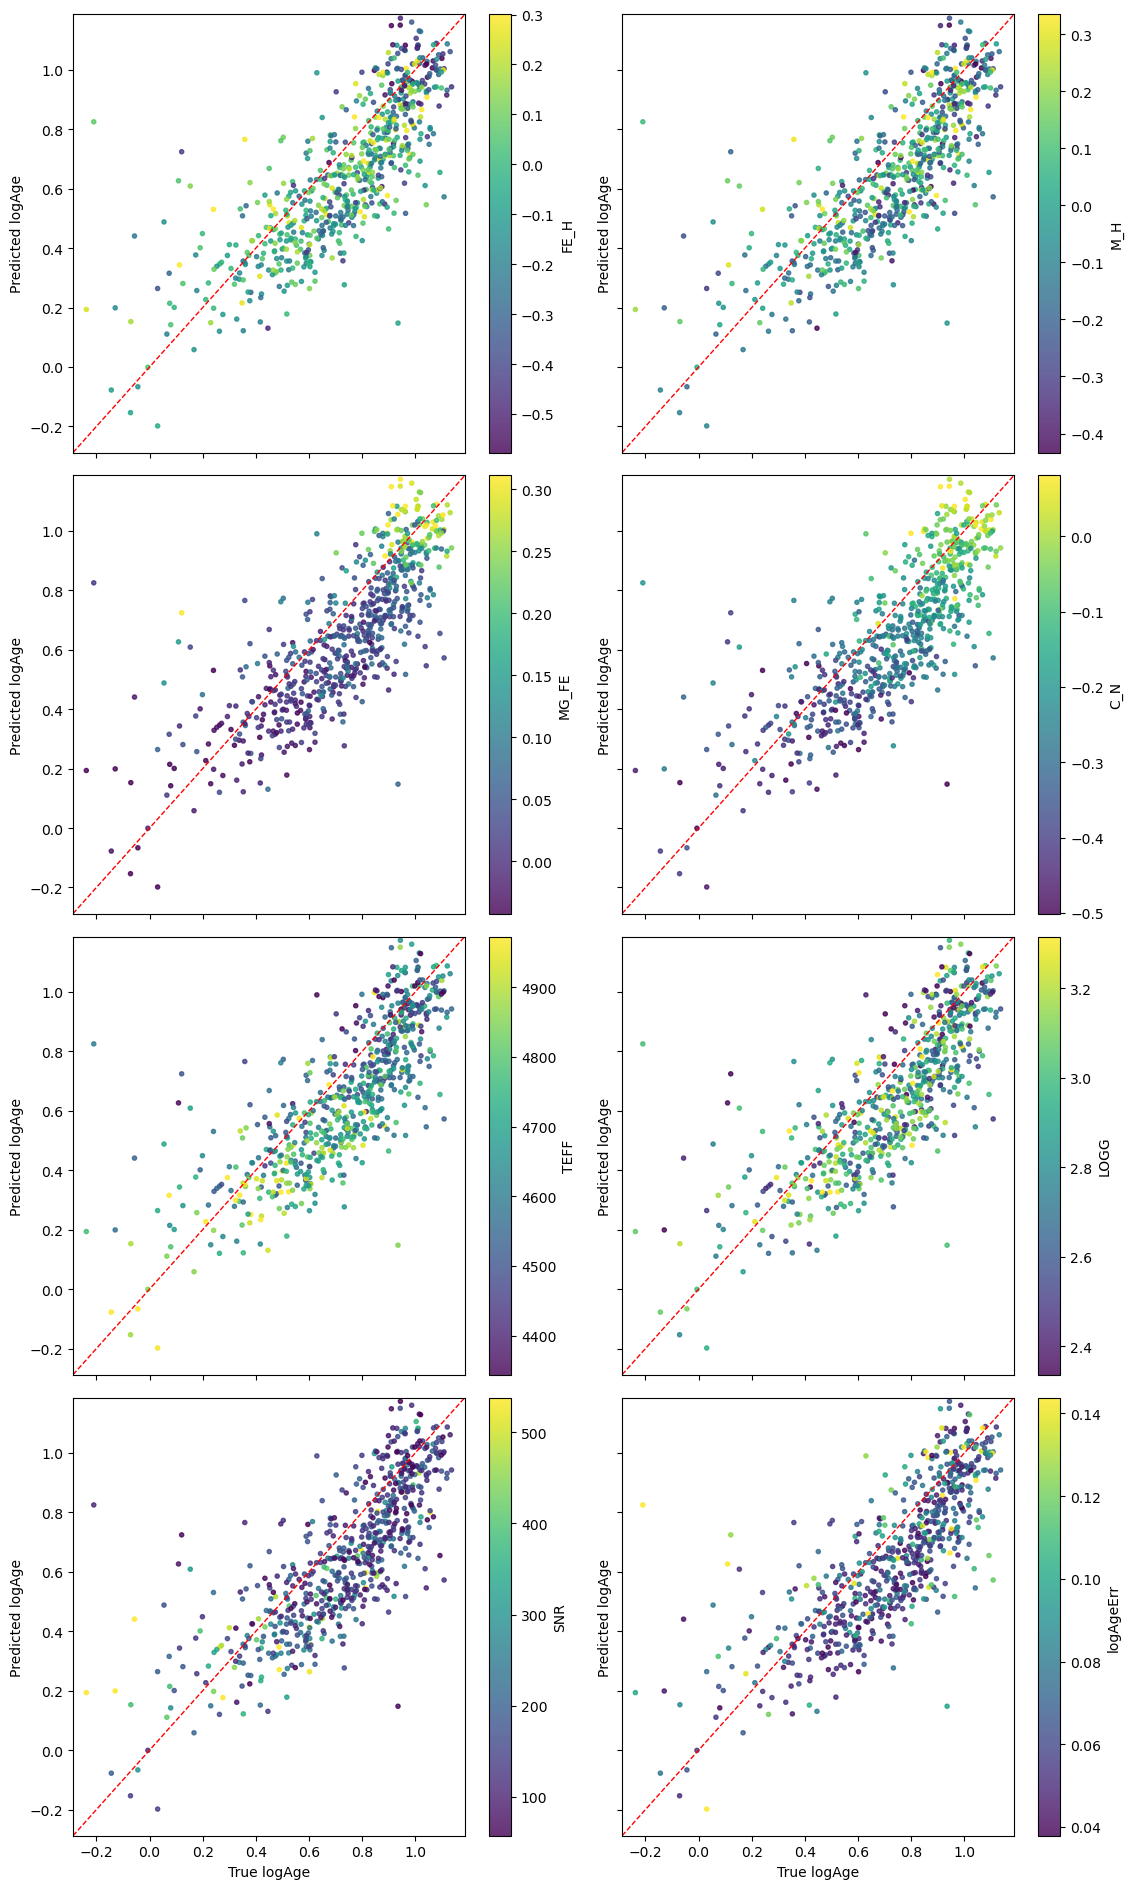

In [13]:
lims = (float(d['true_age'].min()) - 0.05, float(d['true_age'].max()) + 0.05)
fig, axes = plt.subplots(4, 2, figsize=(11.5, 19), sharex=True, sharey=True)
for ax, p in zip(axes.ravel(), PARAMS):
    v = d[p].values
    vmin, vmax = np.nanpercentile(v, [2, 98])
    sc = ax.scatter(d['true_age'], d['pred_median'], c=v, s=9, alpha=0.8,
                    cmap='viridis', vmin=vmin, vmax=vmax)
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    fig.colorbar(sc, ax=ax, label=p)
    ax.set_ylabel('Predicted logAge')
for ax in axes[-1]:
    ax.set_xlabel('True logAge')
plt.tight_layout()
plt.show()

## 5. Residuals vs each parameter

Scatter + decile-binned medians. A flat binned line = no systematic; a tilted
or curved one = the model's errors depend on that parameter. Spearman ρ is
annotated per panel (rank-based, robust to outliers).

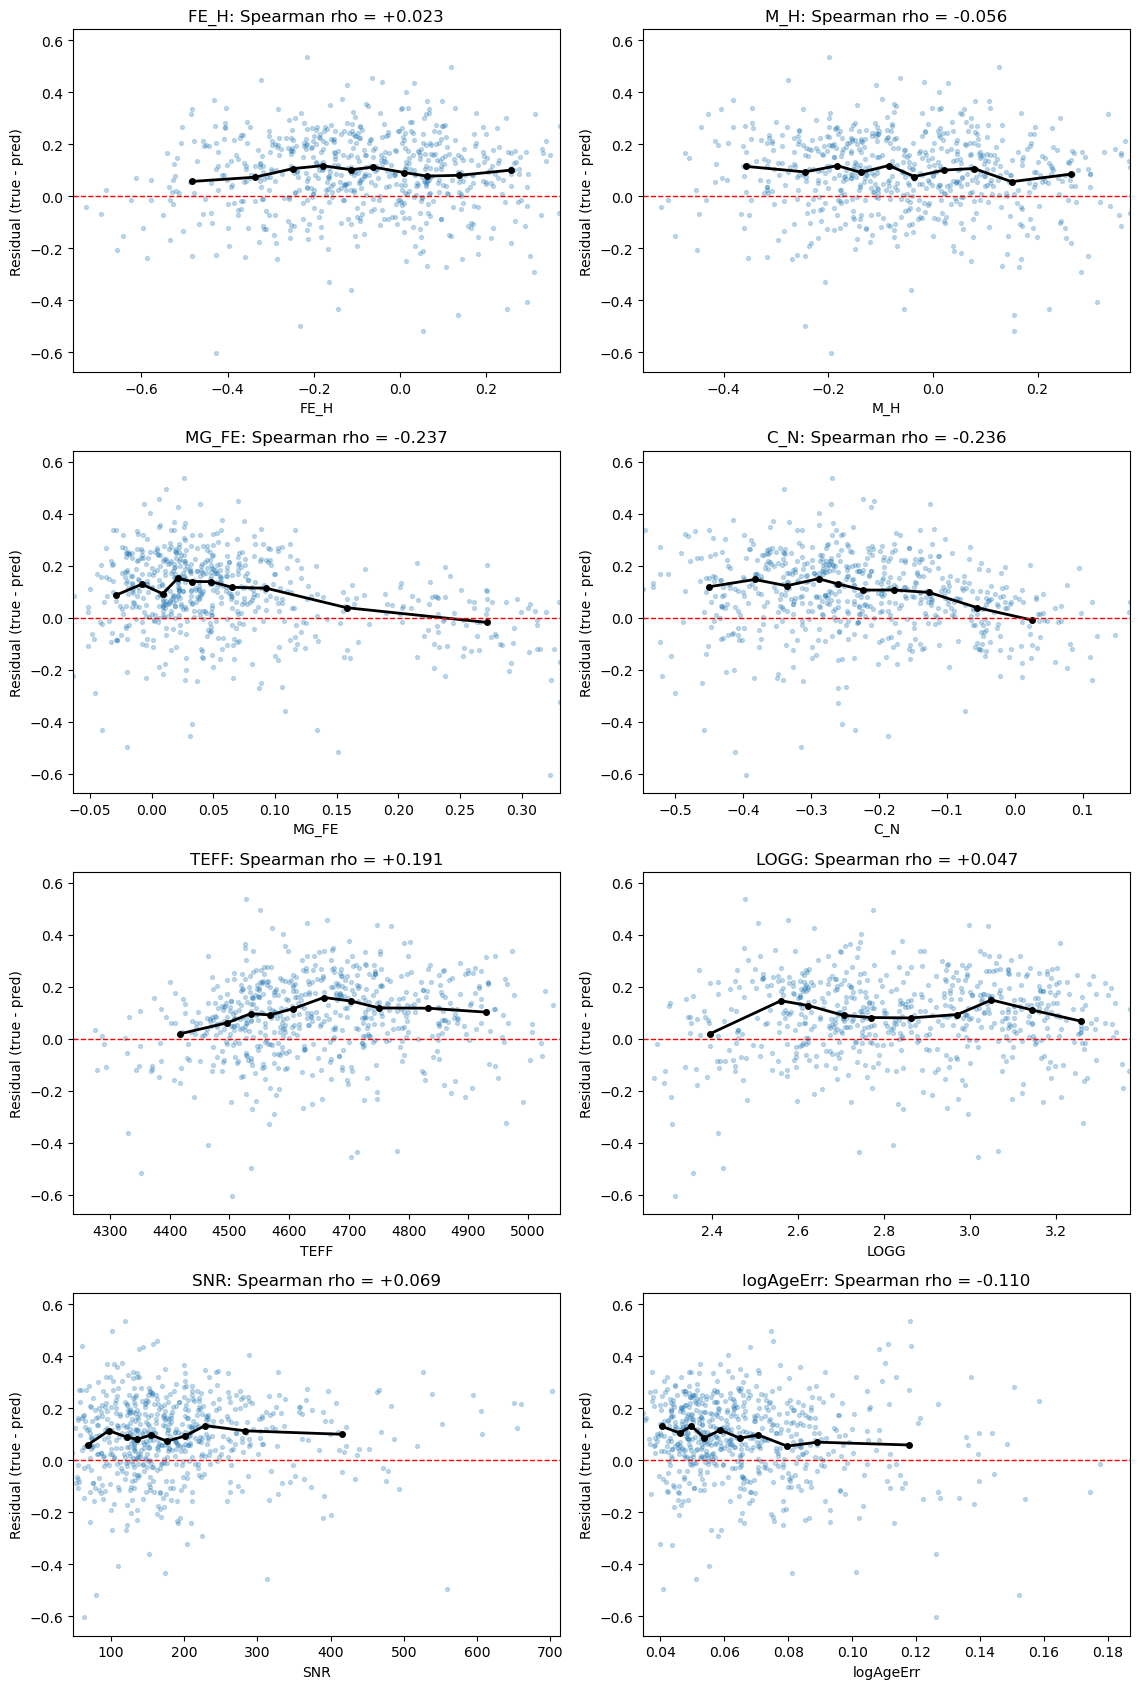

In [14]:
def binned_median(x, y, nbins=10, min_count=8):
    qs = np.nanquantile(x, np.linspace(0, 1, nbins + 1))
    qs = np.unique(qs)
    centers, medians = [], []
    for lo, hi in zip(qs[:-1], qs[1:]):
        m = (x >= lo) & (x <= hi)
        if m.sum() >= min_count:
            centers.append(np.median(x[m]))
            medians.append(np.median(y[m]))
    return np.array(centers), np.array(medians)


resid = d['residual'].values
ylo, yhi = np.percentile(resid, [0.5, 99.5])
pad = 0.2 * (yhi - ylo)

fig, axes = plt.subplots(4, 2, figsize=(11.5, 17))
for ax, p in zip(axes.ravel(), PARAMS):
    v = d[p].values
    rho = float(pd.Series(v).rank().corr(pd.Series(resid).rank()))
    ax.scatter(v, resid, s=8, alpha=0.25, color='tab:blue')
    cx, cy = binned_median(v, resid)
    ax.plot(cx, cy, 'o-', color='k', lw=2, ms=4)
    ax.axhline(0, color='r', ls='--', lw=1)
    vmin, vmax = np.nanpercentile(v, [0.5, 99.5])
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(ylo - pad, yhi + pad)
    ax.set_xlabel(p)
    ax.set_ylabel('Residual (true - pred)')
    ax.set_title(f'{p}: Spearman rho = {rho:+.3f}')
plt.tight_layout()
plt.show()

## 6. Where on the giant branch / in chemical space do the errors live?

Left: Kiel diagram colored by residual (diverging scale, symmetric robust
limits) — clumps of one color mark regions the model mis-predicts, e.g. a
misclassified red-clump contamination island near logg ≈ 2.5, Teff ≈ 4700.
Right: the [Fe/H]–[Mg/Fe] plane, same coloring — thick-disk-like stars
systematically off means a chemistry-dependent age systematic.

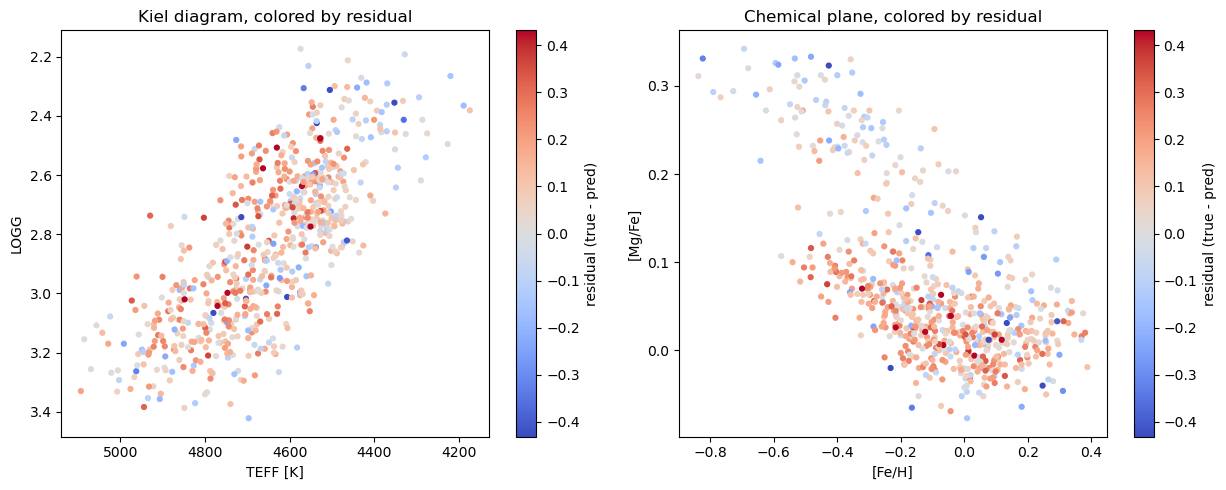

In [15]:
rlim = float(np.percentile(np.abs(d['residual']), 98))
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

sc = axes[0].scatter(d['TEFF'], d['LOGG'], c=d['residual'], s=12,
                     cmap='coolwarm', vmin=-rlim, vmax=rlim)
axes[0].invert_xaxis()
axes[0].invert_yaxis()
axes[0].set_xlabel('TEFF [K]')
axes[0].set_ylabel('LOGG')
axes[0].set_title('Kiel diagram, colored by residual')
fig.colorbar(sc, ax=axes[0], label='residual (true - pred)')

sc = axes[1].scatter(d['FE_H'], d['MG_FE'], c=d['residual'], s=12,
                     cmap='coolwarm', vmin=-rlim, vmax=rlim)
axes[1].set_xlabel('[Fe/H]')
axes[1].set_ylabel('[Mg/Fe]')
axes[1].set_title('Chemical plane, colored by residual')
fig.colorbar(sc, ax=axes[1], label='residual (true - pred)')

plt.tight_layout()
plt.show()

## 7. Verdict table: raw vs debiased trends

Raw-residual trends are contaminated by the shrinkage-vs-age slope wherever a
parameter correlates with age. The debiased residuals remove the mean age
trend, so: **large raw ρ that collapses in the debiased column = shrinkage
artifact; ρ that survives = candidate genuine systematic.**

In [16]:
rows = []
for p in PARAMS:
    v = pd.Series(d[p].values).rank()
    rho_raw = float(v.corr(pd.Series(d['residual'].values).rank()))
    rho_db = float(v.corr(pd.Series(d['residual_debiased'].values).rank()))
    rho_absz = float(v.corr(pd.Series(np.abs(d['calibrated_z'].values)).rank()))
    rows.append({'param': p, 'rho_raw': rho_raw, 'rho_debiased': rho_db,
                 'rho_abs_z': rho_absz,
                 'verdict': ('systematic?' if abs(rho_db) > 0.1 else
                             'shrinkage artifact' if abs(rho_raw) > 0.1 else '-')})
tab = (pd.DataFrame(rows)
         .sort_values('rho_debiased', key=lambda s: s.abs(), ascending=False))
print(tab.to_string(index=False, float_format=lambda x: f'{x:+.3f}'))
print('\nrho_abs_z > 0 means the UNCERTAINTIES are also miscalibrated along')
print('that parameter (|z| grows with it), independent of the mean trend.')

    param  rho_raw  rho_debiased  rho_abs_z     verdict
      C_N   -0.236        -0.351     -0.253 systematic?
    MG_FE   -0.237        -0.340     -0.192 systematic?
     TEFF   +0.191        +0.249     +0.129 systematic?
logAgeErr   -0.110        -0.130     -0.030 systematic?
      SNR   +0.069        +0.101     +0.058 systematic?
     LOGG   +0.047        +0.071     -0.011           -
     FE_H   +0.023        +0.054     +0.029           -
      M_H   -0.056        -0.047     -0.037           -

rho_abs_z > 0 means the UNCERTAINTIES are also miscalibrated along
that parameter (|z| grows with it), independent of the mean trend.


## 8. Drill-down: strongest surviving trend, controlled for age

The debiased trend can still be an age effect in disguise (parameter–age
correlation + an imperfect affine correction). Split the test set into age
terciles: if the residual-vs-parameter line looks the same **within each
tercile**, the trend is genuinely parameter-driven; if it vanishes within
terciles, it was age all along.

Strongest debiased trend: C_N (rho = -0.351)


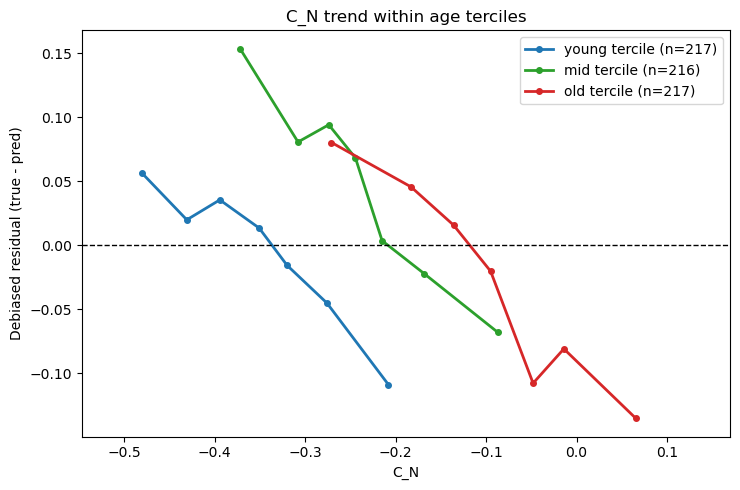

In [17]:
star_param = tab.iloc[0]['param']
print(f'Strongest debiased trend: {star_param} '
      f"(rho = {tab.iloc[0]['rho_debiased']:+.3f})")

terc = pd.qcut(d['true_age'], q=3, labels=['young tercile', 'mid tercile', 'old tercile'])
fig, ax = plt.subplots(figsize=(7.5, 5))
v_all = d[star_param].values
for name, color in zip(['young tercile', 'mid tercile', 'old tercile'],
                       ['tab:blue', 'tab:green', 'tab:red']):
    m = (terc == name).values
    cx, cy = binned_median(v_all[m], d['residual_debiased'].values[m], nbins=7)
    ax.plot(cx, cy, 'o-', color=color, lw=2, ms=4,
            label=f'{name} (n={int(m.sum())})')
ax.axhline(0, color='k', ls='--', lw=1)
vmin, vmax = np.nanpercentile(v_all, [0.5, 99.5])
ax.set_xlim(vmin, vmax)
ax.set_xlabel(star_param)
ax.set_ylabel('Debiased residual (true - pred)')
ax.set_title(f'{star_param} trend within age terciles')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Suspect α-rich stars: impostors that escaped the cut?

The load-time impostor cut is `age_L < 4 Gyr AND [Mg/Fe] > 0.15 AND [C/N] > −0.2`,
which leaves two escape routes: young-looking [C/N] (≤ −0.2), and labels just
above the 4 Gyr window. A deep-blue α-rich star in the maps above (strongly
negative residual) is the model out-voting a suspect label. If most suspects
below sit at 4–8 Gyr labels or have [C/N] ≤ −0.2, consider widening the
impostor cut in the training notebook (and its `prepare_dataset.py` twin) —
at the cost of also removing genuinely intermediate-age α-rich stars.

In [18]:
suspects = d[(d['residual'] < -0.25) & (d['MG_FE'] > 0.15)]
cols = ['APOGEE_ID', 'age', 'C_N', 'MG_FE', 'FE_H',
        'pred_median', 'residual', 'calibrated_z']
print(suspects[cols].sort_values('age').to_string(index=False,
      float_format=lambda v: f'{v: .3f}'))

n = len(suspects)
if n:
    esc_cn = int((suspects['C_N'] <= -0.2).sum())
    esc_age = int((suspects['age'] >= 4).sum())
    print(f'\n{n} suspects; labeled ages '
          f"{suspects['age'].min():.1f}-{suspects['age'].max():.1f} Gyr")
    print(f'escape routes: {esc_cn} with young-looking C/N (<= -0.2), '
          f'{esc_age} labeled above the 4 Gyr cut window (overlapping)')
else:
    print('no alpha-rich stars with residual < -0.25 in this test set')

         APOGEE_ID     age    C_N  MG_FE   FE_H  pred_median  residual  calibrated_z
2M19333417+3917147   1.285 -0.412  0.151  0.053        0.627    -0.518        -2.556
2M19192590+4015158   1.321 -0.396  0.323 -0.427        0.724    -0.603        -2.193
2M19525185+4732421  11.051  0.447  0.331 -0.824        1.368    -0.324        -0.655

3 suspects; labeled ages 1.3-11.1 Gyr
escape routes: 2 with young-looking C/N (<= -0.2), 1 labeled above the 4 Gyr cut window (overlapping)
